# Real BolshoiP vs. SatGen: $z_f$ correlation, MAHs, and host-property corner plot

Compares the 1517 **real** BolshoiP consistent-trees host main branches (`bolshoiP_S13p2_host_ids.csv` sample, logMvir in 13.1-13.3) against the 1517 **SatGen**-generated trees seeded from those same host masses (`data/bolshoi_rep/fid.h5`), matched 1:1 by `tree_index` (SatGen tree `i` was generated with `cfg.M0 = 10.**(Mhost_bolshoi_131[i])`, i.e. the exact z=0 mass of real host `i` -- verified below, `logMvir` agrees exactly between the two tables for every `tree_index`).

Three comparisons, each done for both samples:

1. Spearman $\rho(z_f \mid N_{\rm sub})$ and $\rho(z_f \mid f_{\rm sub})$ vs. mass fraction $f$, jackknife errors, real vs. SatGen overlaid.
2. Every individual host MAH (grey, alpha=0.1) plus the population average (black), real vs. SatGen side by side.
3. A corner plot of `log1pz50`, `logc`, `logNsub`, `logfsub` (host $M_{\rm vir}$ excluded -- identical by construction), real vs. SatGen overlaid.

$N_{\rm sub}$/$f_{\rm sub}$ for BolshoiP come from `bolshoiP_S13p2_mass_matched.csv`; for SatGen from `fid_z0.csv` (both built the same way, `jsm_processh5.ProcessH5`). Spearman correlation is invariant under a monotonic transform, so using the log-quantities in place of raw $N_{\rm sub}$/$f_{\rm sub}$ gives identical $\rho$.

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import itertools
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.simplefilter('ignore')

sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_stats
import jsm_ancillary
import config as cfg


In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0  # inches
single_textwidth = 3.5  # inches
levelz = [1 - 0.99, 1 - 0.95, 1 - 0.68]  # contour levels, matches bolshoi_rep.ipynb / satgen_bolshoi.ipynb


## Load the real BolshoiP MAHs + host properties

`bolshoi_real_MAHs.npz` holds, per host, its own `scale_<id>` / `mvir_<id>` arrays (ascending scale factor, so the **last** entry is $z=0$), plus a `tree_index_to_id` array giving the real consistent-trees halo id for each `tree_index`. `bolshoiP_S13p2_mass_matched.csv` carries `logNsub`/`logfsub`/`logc`/`log1pz50` for those same ids.

In [4]:
d = np.load("../../data/bolshoi_real_trees/bolshoi_real_MAHs.npz")
tree_index_to_id = d["tree_index_to_id"]

bol = pd.read_csv("../../data/bolshoi_rep/bolshoiP_S13p2_mass_matched.csv")
bol["tree_index"] = bol["tree_index"].astype(int)

bol_by_id = bol.set_index("id").loc[tree_index_to_id]
assert list(bol_by_id.index.values) == list(tree_index_to_id)

bolshoi_logNsub = bol_by_id["logNsub"].values
bolshoi_logfsub = bol_by_id["logfsub"].values

print(f"{len(tree_index_to_id)} real BolshoiP host trees")


1517 real BolshoiP host trees


## Load the SatGen mass-matched trees (`fid.h5` + `fid_z0.csv`)

`fid_z0.csv` carries the same host-property columns as `bolshoiP_S13p2_mass_matched.csv` (`logNsub`, `logfsub`, `logc`, `log1pz50`), and its `tree_index` is the same 0..1516 indexing as the real sample -- SatGen tree `tree_index` was generated from real host `tree_index`'s exact z=0 mass. Reindex the raw `fid.h5` MAHs to that same `tree_index` order and confirm the z=0 masses agree exactly.

In [5]:
satgen_zprop = pd.read_csv("../../data/bolshoi_rep/fid_z0.csv").set_index("tree_index").sort_index()

satgen_df = jsm_ancillary.load_sample("../../data/bolshoi_rep/fid.h5")
satgen_df.index = satgen_df.index.astype(int)
satgen_df = satgen_df.loc[satgen_zprop.index]

satgen_MAH = jsm_ancillary.make_matrix(satgen_df, "MAH")
assert satgen_MAH.shape[1] == len(cfg.zsample), "fid.h5 MAH grid does not match the current cfg.zsample -- check the cosmology config"
assert np.allclose(np.log10(satgen_MAH[:, 0]), satgen_zprop["logMvir"].values, atol=1e-3)

satgen_logNsub = satgen_zprop["logNsub"].values
satgen_logfsub = satgen_zprop["logfsub"].values

# sanity check: SatGen was seeded on the exact real host mass, tree_index-for-tree_index
bol_by_treeindex = bol.set_index("tree_index").sort_index()
assert np.allclose(bol_by_treeindex["logMvir"].values, satgen_zprop["logMvir"].values, atol=1e-6)

print(f"{satgen_MAH.shape[0]} SatGen host trees")


1517 SatGen host trees


## $z_f$ machinery

Nearest-index match in a tree's own mass history to `mass_history[0] * f`, for every `f` in `mass_fracs`, then read off that tree's own redshift at that index. `mass_history`/`redshift_grid` must already be ordered with index 0 = $z=0$ (ascending index = higher $z$). One function serves both samples: BolshoiP calls it per-tree against that tree's own native redshift array; SatGen calls it per-tree too, but against the shared `cfg.zsample` grid.

In [6]:
def find_nearest1(array, value):
    idx, val = min(enumerate(array), key=lambda x: abs(x[1] - value))
    return idx

mass_fracs = np.linspace(0.01, 1.0, 100)  # f = M(z) / M(z0)

def compute_zx(mass_history, redshift_grid):
    return np.array([redshift_grid[find_nearest1(mass_history, mass_history[0] * mf)] for mf in mass_fracs])


## Build the $z_f$ matrices (1517 hosts $\times$ 100 mass fractions)

Real BolshoiP arrays are ascending in scale factor (native snapshot order), so $z=0$ is the *last* element -- flip each tree's arrays before calling `compute_zx`. SatGen's `MAH` columns already follow the cfg.zsample convention (index 0 = $z=0$), so no flip is needed there.

In [7]:
host_zx_bolshoi = np.full((len(tree_index_to_id), len(mass_fracs)), np.nan)

for i, hid in enumerate(tree_index_to_id):
    scale = d[f"scale_{hid}"]
    mvir  = d[f"mvir_{hid}"]

    mvir_z0first = mvir[::-1]                      # z=0 first, ascending z with index
    redshift_z0first = (1.0 / scale[::-1]) - 1.0    # matches mvir_z0first index-for-index

    host_zx_bolshoi[i] = compute_zx(mvir_z0first, redshift_z0first)

host_zx_bolshoi = np.log10(1 + host_zx_bolshoi)

host_zx_satgen = np.array([compute_zx(row, cfg.zsample) for row in satgen_MAH])
host_zx_satgen = np.log10(1 + host_zx_satgen)


## Jackknife Spearman correlation vs. mass fraction

For each of the 100 mass fractions, correlate that column of `host_zx` (one $z_f$ value per host) against `logNsub`/`logfsub` (one value per host, independent of $f$), for both samples.

In [8]:
def rho_vs_frac(host_zx, logNsub, logfsub):
    Nrho = np.full(mass_fracs.shape, np.nan)
    frho = np.full(mass_fracs.shape, np.nan)
    Nrho_err = np.full(mass_fracs.shape, np.nan)
    frho_err = np.full(mass_fracs.shape, np.nan)

    for i in range(len(mass_fracs)):
        x = host_zx[:, i]

        mask = np.isfinite(x) & np.isfinite(logNsub)
        Nrho[i], Nrho_err[i], _ = jsm_stats.jackknife_correlation(x[mask], logNsub[mask])

        mask = np.isfinite(x) & np.isfinite(logfsub)
        frho[i], frho_err[i], _ = jsm_stats.jackknife_correlation(x[mask], logfsub[mask])

    return Nrho, Nrho_err, frho, frho_err

bolshoi_Nrho, bolshoi_Nrho_err, bolshoi_frho, bolshoi_frho_err = rho_vs_frac(host_zx_bolshoi, bolshoi_logNsub, bolshoi_logfsub)
satgen_Nrho, satgen_Nrho_err, satgen_frho, satgen_frho_err = rho_vs_frac(host_zx_satgen, satgen_logNsub, satgen_logfsub)


## Plot 1: $\rho_S(z_f \mid N_{\rm sub})$ and $\rho_S(z_f \mid f_{\rm sub})$, real vs. SatGen

Jackknife error shown as a shaded band. $\rho$ is undefined right at $f=1$ (every tree's own $z_f \to z=0$ there by construction, ~zero variance across the sample) -- the lines going noisy as $f \to 1$ is expected, not a bug.

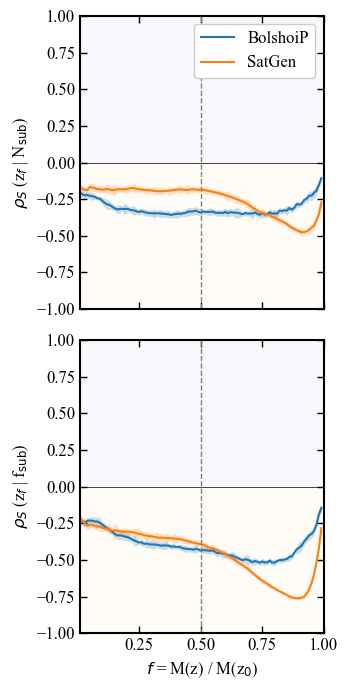

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

ax[0].plot(mass_fracs, bolshoi_Nrho, color="C0", lw=1.5, label="BolshoiP")
ax[0].fill_between(mass_fracs, bolshoi_Nrho - bolshoi_Nrho_err, bolshoi_Nrho + bolshoi_Nrho_err, color="C0", alpha=0.25, lw=0)
ax[0].plot(mass_fracs, satgen_Nrho, color="C1", lw=1.5, label="SatGen")
ax[0].fill_between(mass_fracs, satgen_Nrho - satgen_Nrho_err, satgen_Nrho + satgen_Nrho_err, color="C1", alpha=0.25, lw=0)

ax[1].plot(mass_fracs, bolshoi_frho, color="C0", lw=1.5, label="BolshoiP")
ax[1].fill_between(mass_fracs, bolshoi_frho - bolshoi_frho_err, bolshoi_frho + bolshoi_frho_err, color="C0", alpha=0.25, lw=0)
ax[1].plot(mass_fracs, satgen_frho, color="C1", lw=1.5, label="SatGen")
ax[1].fill_between(mass_fracs, satgen_frho - satgen_frho_err, satgen_frho + satgen_frho_err, color="C1", alpha=0.25, lw=0)

ax[0].set_xlim(0.01, 1)
ax[0].set_ylim(-1, 1)

for a in ax:
    a.axvline(0.5, color="grey", ls="--", lw=1)
    a.axhline(0, color="k", lw=0.5)
    a.fill_between(mass_fracs, [0]*mass_fracs.shape[0], [1]*mass_fracs.shape[0], color="lightsteelblue", alpha=0.1)
    a.fill_between(mass_fracs, [-1]*mass_fracs.shape[0], [0]*mass_fracs.shape[0], color="bisque", alpha=0.1)

ax[0].set_ylabel(r"$\rho_S$ (z$_f$ | N$_{\rm sub}$)")
ax[1].set_ylabel(r"$\rho_S$ (z$_f$ | f$_{\rm sub}$)")
ax[1].set_xlabel("$f$ = M(z) / M(z$_0$)")
ax[1].set_xticks([0.25, 0.5, 0.75, 1])
ax[0].legend(framealpha=1)

plt.tight_layout()
# plt.savefig("../../figures/zf_correlation_bolshoi_vs_satgen.pdf", bbox_inches="tight")
plt.show()


## Plot 2: unique host MAHs, real vs. SatGen

Every individual host main branch (grey, alpha=0.1) plus the population average (black), in $\log(1+z)$. BolshoiP MAHs sit on each tree's own native, irregular scale-factor sampling, so the average is computed by interpolating each host onto a common $\log(1+z)$ grid -- only over the range that host actually covers, no extrapolation -- then averaging. SatGen MAHs already share the `cfg.zsample` grid, so the average is a direct `nanmean`. Panels share a y-axis (mass) for a direct comparison; x-ranges are left as each sample's own native span.

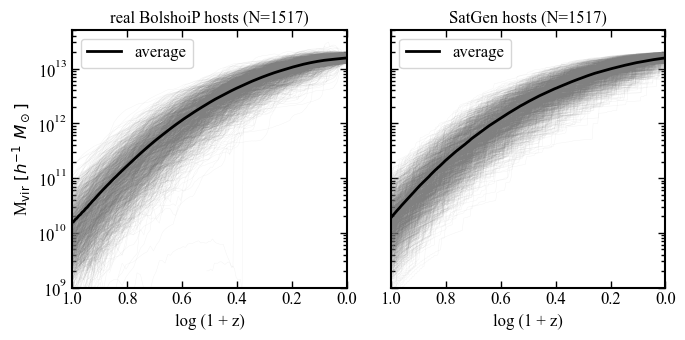

In [10]:
bolshoi_log1pz_list = []
bolshoi_mvir_list = []

for hid in tree_index_to_id:
    scale = d[f"scale_{hid}"]
    mvir  = d[f"mvir_{hid}"]

    log1pz_z0first = np.log10(1 + (1.0 / scale[::-1] - 1.0))
    mvir_z0first = mvir[::-1]

    bolshoi_log1pz_list.append(log1pz_z0first)
    bolshoi_mvir_list.append(mvir_z0first)

bolshoi_logz_grid = np.linspace(0, np.concatenate(bolshoi_log1pz_list).max(), 200)
bolshoi_mvir_interp = np.full((len(tree_index_to_id), len(bolshoi_logz_grid)), np.nan)

for i, (log1pz_z0first, mvir_z0first) in enumerate(zip(bolshoi_log1pz_list, bolshoi_mvir_list)):
    within = (bolshoi_logz_grid >= log1pz_z0first.min()) & (bolshoi_logz_grid <= log1pz_z0first.max())
    bolshoi_mvir_interp[i, within] = np.interp(bolshoi_logz_grid[within], log1pz_z0first, mvir_z0first)

bolshoi_mean_mvir = np.nanmean(bolshoi_mvir_interp, axis=0)

satgen_log1pz = np.log10(1 + cfg.zsample)
satgen_mean_mvir = np.nanmean(satgen_MAH, axis=0)

fig, ax = plt.subplots(1, 2, figsize=(double_textwidth, single_textwidth), sharey=True, sharex=True)

for log1pz_z0first, mvir_z0first in zip(bolshoi_log1pz_list, bolshoi_mvir_list):
    ax[0].plot(log1pz_z0first, mvir_z0first, color="grey", lw=0.3, alpha=0.1)
ax[0].plot(bolshoi_logz_grid, bolshoi_mean_mvir, color="k", lw=2, label="average")

for row in satgen_MAH:
    ax[1].plot(satgen_log1pz, row, color="grey", lw=0.3, alpha=0.1)
ax[1].plot(satgen_log1pz, satgen_mean_mvir, color="k", lw=2, label="average")

ax[0].set_yscale("log")
ax[0].set_xlim(1, 0)
ax[0].set_ylim(1e9, 5e13)

ax[0].set_title(f"real BolshoiP hosts (N={len(tree_index_to_id)})")
ax[1].set_title(f"SatGen hosts (N={satgen_MAH.shape[0]})")

ax[0].set_ylabel(r"M$_{\rm vir}\ [h^{-1}\ M_\odot]$")
for a in ax:
    a.set_xlabel("log (1 + z)")
    a.legend()

plt.tight_layout()
plt.show()


(1.0, 0.0)

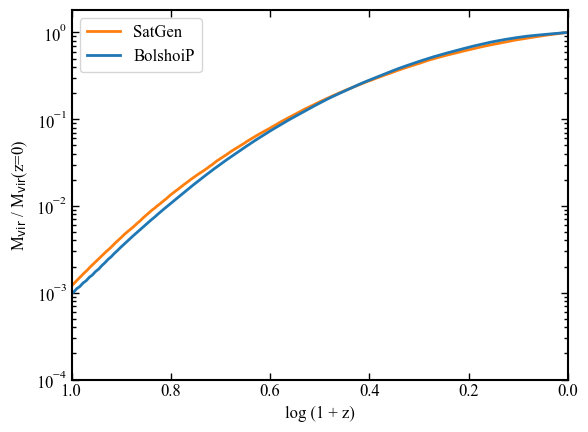

In [17]:
plt.plot(satgen_log1pz, satgen_mean_mvir/satgen_mean_mvir[0], color="C1", lw=2, label="SatGen")
plt.plot(bolshoi_logz_grid, bolshoi_mean_mvir/bolshoi_mean_mvir[0], color="C0", lw=2, label="BolshoiP")
plt.legend()

plt.yscale("log")
plt.xlabel("log (1 + z)")
plt.ylabel("M$_{\\rm vir}$ / M$_{\\rm vir}$(z=0) ")
plt.ylim(1e-4)
plt.xlim(1, 0)

## Plot 3: corner plot, real vs. SatGen

Diagonal = 1D KDE marginals, lower triangle = 2D KDE contours + Spearman $\rho$ annotated per sample -- same `plot_corner_with_corr` layout as `bolshoi_rep.ipynb` / `epsilon_vs_fiducial.ipynb`, here comparing the real BolshoiP sample against its SatGen realization instead of comparing SatGen variants to each other. Matched by `tree_index` (real host $i$ against the SatGen tree seeded on host $i$'s exact mass). $M_{\rm vir}$ is excluded from the panel keys -- identical by construction, already verified above.

In [12]:
def plot_corner_with_corr(matched, models, keys, paramNames, colors,
                           paramRanges=None, figsize=7):
    """
    Corner comparison between an arbitrary number of models using a matched
    dataframe, with Spearman correlation coefficients annotated in each
    off-diagonal panel.

    models : list of (suffix, label) tuples, e.g. [("real", "BolshoiP"), ("satgen", "SatGen")]
    keys   : column base-names to compare, expected in matched as f"{key}_{suffix}"
    paramRanges : list of [lo, hi] per key, or None to auto-range from the data (1st/99th percentile + pad)
    """
    model_colors = dict(zip([m for _, m in models], colors))

    model_chains = {}
    model_rho = {}

    for suffix, model in models:
        cols = [f"{k}_{suffix}" for k in keys]
        chain = matched[cols].copy()
        chain.columns = keys

        mask = ~chain.isna().any(axis=1)
        chain = chain.loc[mask].reset_index(drop=True)

        pair_rho = {}
        for k1, k2 in itertools.combinations(keys, 2):
            pair_rho[(k1, k2)] = jsm_stats.correlation(chain[k1].values, chain[k2].values)

        model_chains[model] = chain
        model_rho[model] = pair_rho

    if paramRanges is None:
        paramRanges = []
        for k in keys:
            allvals = np.concatenate([model_chains[m][k].values for _, m in models])
            allvals = allvals[np.isfinite(allvals)]
            lo, hi = np.nanpercentile(allvals, [1, 99])
            pad = 0.5 * (hi - lo if hi > lo else 1.0)
            paramRanges.append([lo - pad, hi + pad])

    nDim = len(keys)
    fig, axes = plt.subplots(nDim, nDim, figsize=(figsize, figsize))

    for i in range(nDim):
        for j in range(nDim):
            ax = axes[i, j]

            if j > i:
                ax.axis("off")
                continue

            if i == j:
                for _, model in models:
                    chain = model_chains[model]
                    sns.kdeplot(chain[keys[i]], ax=ax, color=model_colors[model], fill=False, lw=1.8)
                ax.set_xlim(paramRanges[i])
                ax.set_yticks([])

            else:
                for _, model in models:
                    chain = model_chains[model]
                    sns.kdeplot(x=chain[keys[j]], y=chain[keys[i]], ax=ax, color=model_colors[model],
                                levels=levelz, fill=False, linewidths=1.3)
                ax.set_xlim(paramRanges[j])
                ax.set_ylim(paramRanges[i])

                pair = (keys[j], keys[i])
                first_model = models[0][1]
                if pair not in model_rho[first_model]:
                    pair = (keys[i], keys[j])

                y0 = 0.91
                for _, model in models:
                    rho = model_rho[model][pair]
                    ax.text(0.02, y0, r"$\rho$=" + f"{rho:.2f}", transform=ax.transAxes, fontsize=10,
                            color=model_colors[model],
                            bbox=dict(boxstyle="round", facecolor="white", alpha=1, edgecolor="white", pad=0.01))
                    y0 -= 0.1

            if i < nDim - 1:
                ax.set_xticklabels([])
                ax.set_xlabel("")
            else:
                ax.set_xlabel(paramNames[j], fontsize=12, fontfamily="Times")

            if j > 0 or i == j:
                ax.set_yticklabels([])
                ax.set_ylabel("")
            else:
                ax.set_ylabel(paramNames[i], fontsize=12, fontfamily="Times")

            ax.tick_params(labelsize=10)
            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontfamily("Times")

    handles = [plt.Line2D([0], [0], color=model_colors[model], lw=1.8, label=model) for _, model in models]
    fig.legend(handles=handles, loc="upper right", fontsize=12, frameon=False)

    plt.subplots_adjust(wspace=0.08, hspace=0.08)
    plt.tight_layout()
    return fig


1517 trees matched by tree_index


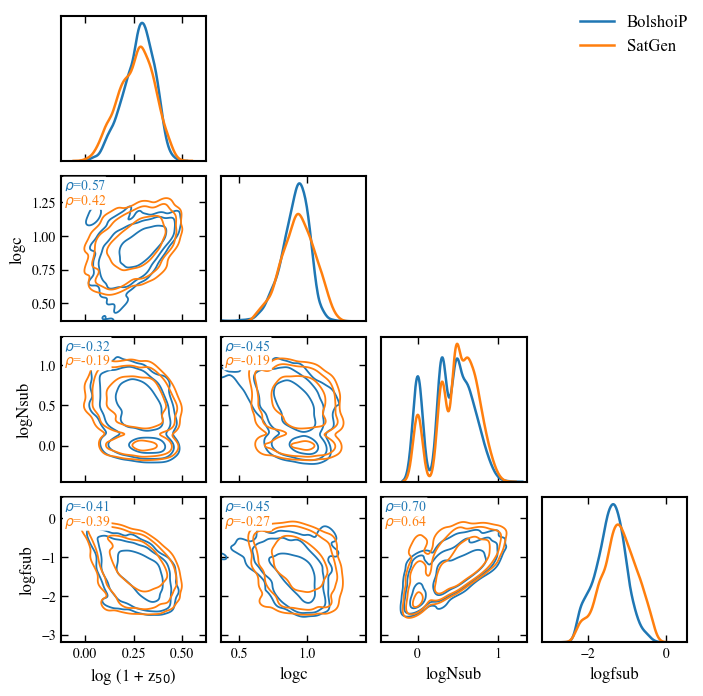

In [13]:
def add_suffix(df, suf):
    return df.rename(columns={c: f"{c}_{suf}" for c in df.columns if c != "tree_index"})

models = [("real", "BolshoiP"), ("satgen", "SatGen")]
colors = ("C0", "C1")

matched = add_suffix(bol_by_treeindex.reset_index(), "real").merge(
    add_suffix(satgen_zprop.reset_index(), "satgen"), on="tree_index", how="inner")

print(f"{len(matched)} trees matched by tree_index")

keys = ["log1pz50", "logc", "logNsub", "logfsub"]
paramNames = ["log (1 + z$_{50}$)", "logc", "logNsub", "logfsub"]

fig = plot_corner_with_corr(matched, models=models, keys=keys, paramNames=paramNames,
                             colors=colors, figsize=7.0)
# fig.savefig("../../figures/corner_bolshoi_vs_satgen.pdf", bbox_inches="tight")
